# Unsupervised Cross-Modal Anomaly Detection in Brain CT–MRI Imaging

**Student Name & ID:** *DIVAGAR N | 2024ac05086*  
**Student Name & ID:** *SUDEEP REGE | 2024ad05370*   
**Student Name & ID:** *ANKITA BHATNAGAR | 2024aa05128*   
**Student Name & ID:** *SHUBHAM BALIRAM SONGIRE | 2024aa05126*   
**Student Name & ID:** *HITESH KUMAR | 2024aa05127*   

## Problem Statement 2
This project focuses on detecting anomalies in brain imaging data using an
**unsupervised cross-modal learning framework**.

Paired CT and MRI scans are used to learn normal anatomical patterns.
Since labeled anomaly data is unavailable, anomalies are identified using:
- Reconstruction errors
- Feature-space outliers
- Cross-modal latent inconsistencies

This approach closely reflects real-world medical scenarios where abnormal
samples are rare or unlabeled.


## Objectives

1. Preprocess and align paired CT–MRI brain images
2. Learn normal anatomical representations using autoencoders
3. Detect anomalies using:
   - Autoencoder reconstruction error
   - One-Class SVM and Isolation Forest
   - Cross-modal latent feature divergence
4. Analyze anomaly score distributions and model behavior


In [1]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_curve, auc


## Device Configuration
GPU is used if available to accelerate training.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## Dataset Structure

The dataset follows a domain-separated structure:

```
Dataset/
│
├── images/
│   ├── trainA/  → CT images (normal training data)
│   ├── trainB/  → MRI images (normal training data)
│   ├── testA/   → CT test images
│   ├── testB/   → MRI test images
│
├── unseen_demo_images/
│   ├── ct/
│   ├── mri/
```
CT–MRI pairs are formed using **index-based alignment after sorting filenames**.
No anomaly labels are provided, making this a fully unsupervised setting.


## Custom Dataset Loader

This dataset class:
- Loads CT and MRI images
- Normalizes them independently
- Resizes them to a fixed resolution
- Maintains CT–MRI correspondence by index



In [3]:
class CTMRIDataset(Dataset):
    def __init__(self, root_dir, split="train", img_size=256):
        self.ct_dir = os.path.join(root_dir, "images", f"{split}A")
        self.mri_dir = os.path.join(root_dir, "images", f"{split}B")

        self.ct_files = sorted(os.listdir(self.ct_dir))
        self.mri_files = sorted(os.listdir(self.mri_dir))

        self.length = min(len(self.ct_files), len(self.mri_files))
        self.img_size = img_size

    def _load_image(self, path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = img.astype(np.float32) / 255.0
        return torch.tensor(img).unsqueeze(0)

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        ct = self._load_image(os.path.join(self.ct_dir, self.ct_files[idx]))
        mri = self._load_image(os.path.join(self.mri_dir, self.mri_files[idx]))
        return ct, mri


In [4]:
train_dataset = CTMRIDataset(
    root_dir="/kaggle/input/ct-to-mri-cgan/Dataset",
    split="train"
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

test_dataset = CTMRIDataset(
    root_dir="/kaggle/input/ct-to-mri-cgan/Dataset",
    split="test"
)

test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)


## Convolutional Autoencoder

Autoencoders are trained on normal data to reconstruct input images.
High reconstruction error indicates deviation from learned normal patterns.


In [5]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


In [6]:
ct_ae = AutoEncoder().to(device)
mri_ae = AutoEncoder().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    list(ct_ae.parameters()) + list(mri_ae.parameters()), lr=1e-3
)


epochs = 15
prev_loss = float("inf")
patience = 3
counter = 0

for epoch in range(epochs):
    total_loss = 0
    for ct, mri in train_loader:
        ct, mri = ct.to(device), mri.to(device)

        ct_rec, _ = ct_ae(ct)
        mri_rec, _ = mri_ae(mri)

        loss = criterion(ct_rec, ct) + criterion(mri_rec, mri)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    if abs(prev_loss - avg_loss) < 1e-4:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break
    else:
        counter = 0

    prev_loss = avg_loss


Epoch 1, Loss: 0.0320
Epoch 2, Loss: 0.0062
Epoch 3, Loss: 0.0042
Epoch 4, Loss: 0.0032
Epoch 5, Loss: 0.0027
Epoch 6, Loss: 0.0023
Epoch 7, Loss: 0.0020
Epoch 8, Loss: 0.0018
Epoch 9, Loss: 0.0017
Epoch 10, Loss: 0.0016
Epoch 11, Loss: 0.0014
Epoch 12, Loss: 0.0014
Epoch 13, Loss: 0.0013
Epoch 14, Loss: 0.0012
Epoch 15, Loss: 0.0011


### Training Summary

Both CT and MRI autoencoders are trained exclusively on normal training data.
The objective is to learn compact latent representations of normal anatomical
patterns. Anomalies are not used during training, preserving the unsupervised
nature of the framework.


In [7]:
def reconstruction_error(model, x):
    with torch.no_grad():
        recon, _ = model(x)
        return torch.mean((recon - x) ** 2, dim=[1,2,3]).cpu().numpy()


In [8]:
def extract_features(model, loader):
    feats = []
    with torch.no_grad():
        for ct, _ in loader:
            ct = ct.to(device)
            _, z = model(ct)
            feats.append(z.view(z.size(0), -1).cpu().numpy())
    return np.vstack(feats)


### One-Class Learning in Latent Space

Latent representations extracted from the CT autoencoder are used for
feature-space anomaly detection. Two unsupervised outlier detection
methods are applied:

- One-Class SVM (boundary-based detection)
- Isolation Forest (tree-based isolation of outliers)

These approaches identify deviations directly in feature space rather than
pixel space, providing complementary anomaly signals.


In [9]:
features = extract_features(ct_ae, train_loader)

ocsvm = OneClassSVM(kernel="rbf", nu=0.05)
ocsvm.fit(features)
svm_scores = -ocsvm.decision_function(features)

iso = IsolationForest(contamination=0.05)
iso.fit(features)
iso_scores = -iso.decision_function(features)


### Cross-Modal Latent Consistency

To preserve the cross-modal nature of the framework, latent representations
from CT and MRI autoencoders are compared using Euclidean distance.
Higher divergence indicates potential inconsistency between modalities,
which may correspond to abnormal structural patterns.


In [10]:
def cross_modal_distance(ct_model, mri_model, loader):
    distances = []
    with torch.no_grad():
        for ct, mri in loader:
            ct, mri = ct.to(device), mri.to(device)
            _, z_ct = ct_model(ct)
            _, z_mri = mri_model(mri)
            z_ct = z_ct.view(z_ct.size(0), -1)
            z_mri = z_mri.view(z_mri.size(0), -1)
            distances.extend(torch.norm(z_ct - z_mri, dim=1).cpu().numpy())
    return np.array(distances)


In [11]:
cross_modal_scores = cross_modal_distance(ct_ae, mri_ae, train_loader)


## Visualization of Structural Synthetic Anomalies

To qualitatively validate synthetic anomaly generation, we visualize
two examples for each structural anomaly type:
- Square occlusions
- Circular lesions
- Irregular blob anomalies

This visualization is used solely for inspection and reporting, while
quantitative evaluation relies on randomized structural anomaly injection.


In [12]:
def get_brain_mask(ct_img, threshold=0.1):
    """
    ct_img: Tensor of shape (1, 1, H, W)
    Returns: Boolean mask of brain region
    """
    img = ct_img[0, 0]
    mask = img > threshold

    mask_np = mask.cpu().numpy().astype(np.uint8)
    kernel = np.ones((7, 7), np.uint8)
    mask_np = cv2.morphologyEx(mask_np, cv2.MORPH_CLOSE, kernel)

    return torch.tensor(mask_np, device=ct_img.device, dtype=torch.bool)


In [13]:
def sample_point_inside_mask(mask):
    ys, xs = torch.where(mask)
    idx = np.random.randint(0, len(xs))
    return ys[idx].item(), xs[idx].item()


In [14]:
def square_mask(img):
    img = img.clone()
    _, _, H, W = img.shape

    brain_mask = get_brain_mask(img)
    cy, cx = sample_point_inside_mask(brain_mask)

    size = np.random.randint(H // 25, H // 12)

    y1 = max(0, cy - size // 2)
    y2 = min(H, cy + size // 2)
    x1 = max(0, cx - size // 2)
    x2 = min(W, cx + size // 2)

    mask = torch.zeros((H, W), device=img.device, dtype=torch.bool)
    mask[y1:y2, x1:x2] = True

    noise = torch.randn((H, W), device=img.device) * 0.2
    mask = mask & (noise > -0.3)

    mask = mask & brain_mask

    img[:, :, mask] = 0.0
    return img


def circular_mask(img):
    img = img.clone()
    _, _, H, W = img.shape

    brain_mask = get_brain_mask(img)
    cy, cx = sample_point_inside_mask(brain_mask)

    r = np.random.randint(H // 30, H // 15)

    Y, X = torch.meshgrid(
        torch.arange(H, device=img.device),
        torch.arange(W, device=img.device),
        indexing="ij"
    )

    circle = ((X - cx)**2 + (Y - cy)**2 <= r**2)
    circle = circle & brain_mask  

    img[:, :, circle] = 0.0
    return img


def blob_mask(img):
    img = img.clone()
    _, _, H, W = img.shape

    brain_mask = get_brain_mask(img)
    cy, cx = sample_point_inside_mask(brain_mask)

    r = np.random.randint(H // 30, H // 15)

    Y, X = torch.meshgrid(
        torch.arange(H, device=img.device),
        torch.arange(W, device=img.device),
        indexing="ij"
    )

    dist = torch.sqrt((X - cx)**2 + (Y - cy)**2)
    noise = torch.randn_like(dist) * (r * 0.3)

    blob = (dist + noise < r)
    blob = blob & brain_mask  

    img[:, :, blob] = 0.0
    return img


def inject_structural_anomaly_per_image(batch):
    anomalous = []

    for i in range(batch.size(0)):
        img = batch[i:i+1]

        anomaly_type = random.choice(["square", "circle", "blob"])

        if anomaly_type == "square":
            img = square_mask(img)

        elif anomaly_type == "circle":
            img = circular_mask(img)

        elif anomaly_type == "blob":
            img = blob_mask(img)

        anomalous.append(img)

    return torch.cat(anomalous, dim=0)


To improve realism, synthetic anomalies were generated with slight boundary
irregularities rather than perfect geometric shapes, better simulating
organic pathological structures.


In [15]:
def visualize_structural_anomalies(ct_batch):
    ct_batch = ct_batch.to(device)

    anomaly_types = [
        ("Square Occlusion", square_mask),
        ("Circular Lesion", circular_mask),
        ("Irregular Blob", blob_mask),
    ]

    examples_per_type = 2
    total_rows = len(anomaly_types) * examples_per_type

    plt.figure(figsize=(12, 3 * total_rows))

    row = 0
    img_idx = 0
    num_imgs = ct_batch.size(0)

    for name, func in anomaly_types:
        for _ in range(examples_per_type):
            ct = ct_batch[img_idx % num_imgs : (img_idx % num_imgs) + 1]
            img_idx += 1

            anom = func(ct)

            # Normal image
            plt.subplot(total_rows, 3, row*3 + 1)
            plt.imshow(ct[0, 0].cpu(), cmap="gray")
            plt.title("Normal")
            plt.axis("off")

            # Synthetic anomaly
            plt.subplot(total_rows, 3, row*3 + 2)
            plt.imshow(anom[0, 0].cpu(), cmap="gray")
            plt.title(name)
            plt.axis("off")

            # Difference map
            plt.subplot(total_rows, 3, row*3 + 3)
            diff = torch.abs(ct[0, 0] - anom[0, 0])
            plt.imshow(diff.cpu(), cmap="hot")
            plt.title("Difference")
            plt.axis("off")

            row += 1

    plt.tight_layout()
    plt.show()



For evaluation, synthetic anomalies are injected exclusively into CT images.
CT imaging offers more stable intensity characteristics, enabling reliable
brain masking and controlled structural anomaly simulation. MRI data is used
to learn complementary representations and to enforce cross-modal consistency
between modalities. This design preserves the cross-modal nature of the
framework while allowing interpretable and robust anomaly evaluation.


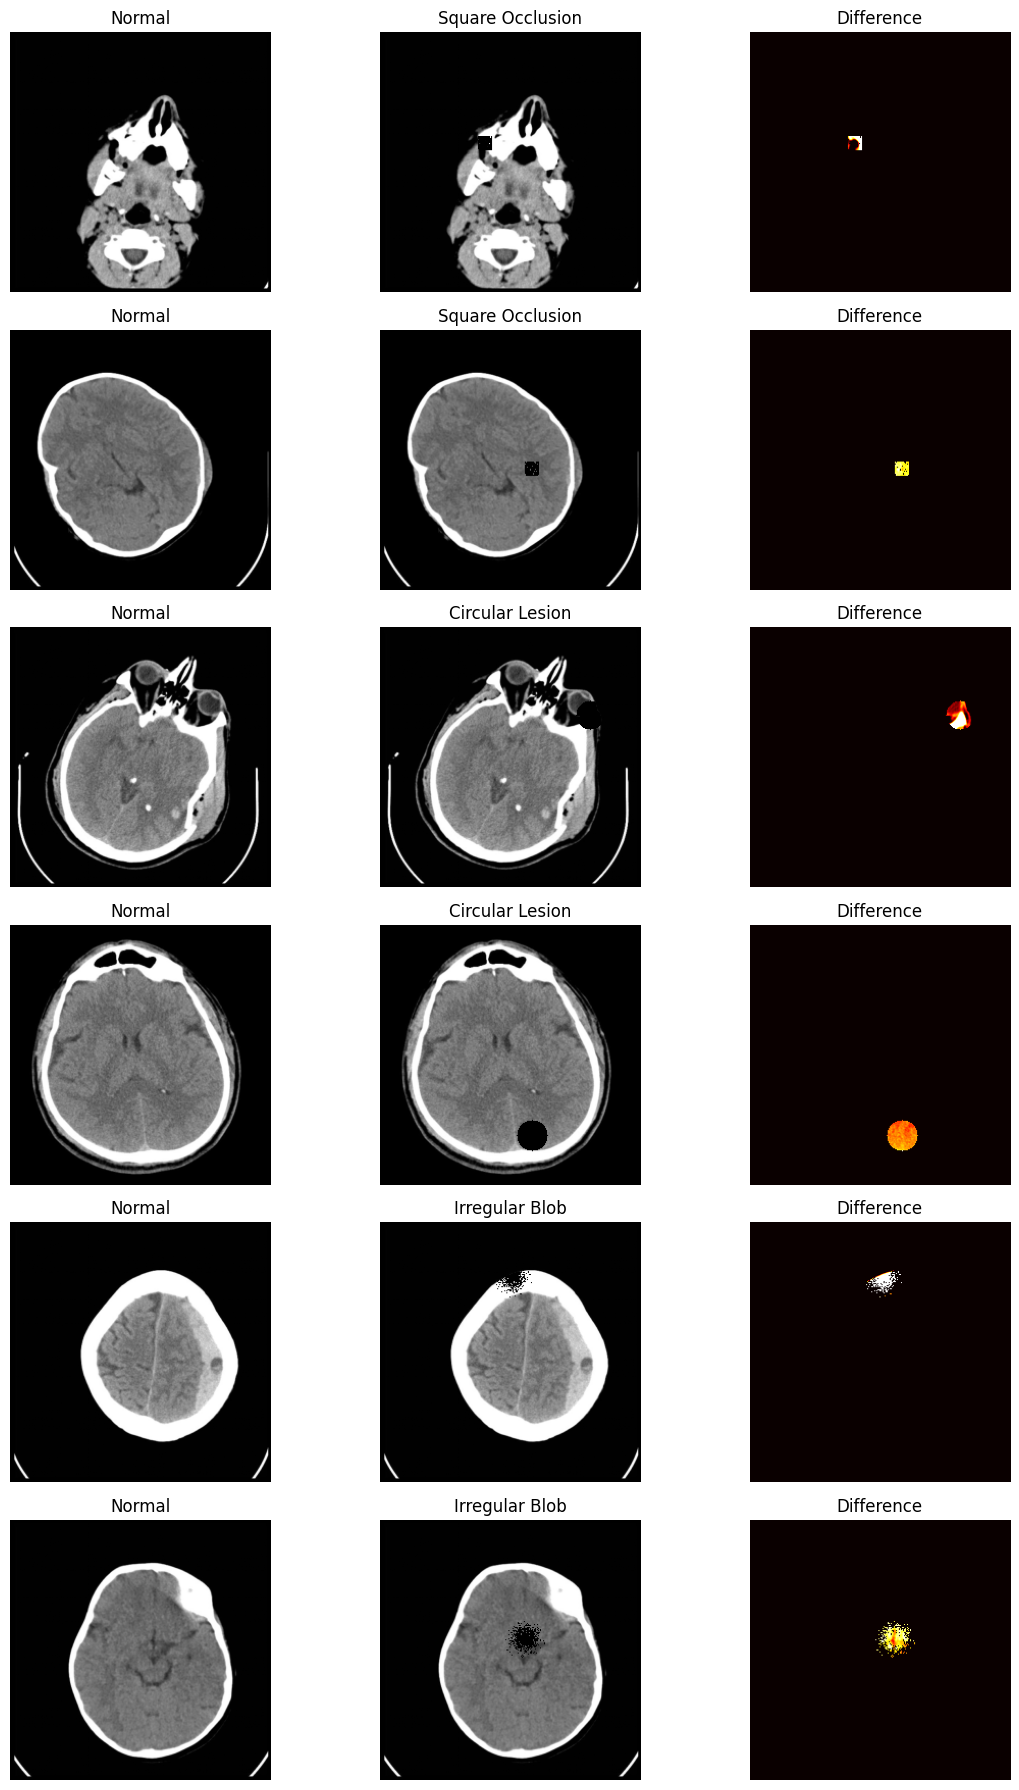

In [21]:
ct_batch, _ = next(iter(test_loader))
visualize_structural_anomalies(ct_batch)


In [22]:
# Reconstruction

normal_rec = []
anomaly_rec = []

ct_ae.eval()

with torch.no_grad():
    for ct, _ in test_loader:
        ct = ct.to(device)
        normal_rec.extend(reconstruction_error(ct_ae, ct))

        ct_anom = inject_structural_anomaly_per_image(ct)
        anomaly_rec.extend(reconstruction_error(ct_ae, ct_anom))

y_true_rec = np.array([0]*len(normal_rec) + [1]*len(anomaly_rec))
y_score_rec = np.array(normal_rec + anomaly_rec)

fpr_rec, tpr_rec, _ = roc_curve(y_true_rec, y_score_rec)
auc_rec = auc(fpr_rec, tpr_rec)

auc_rec


np.float64(0.7204716585732455)

In [23]:
# One-Class SVM 

normal_svm = []
anomaly_svm = []

with torch.no_grad():
    for ct, _ in test_loader:
        ct = ct.to(device)

        feats = ct_ae.encoder(ct).view(ct.size(0), -1).cpu().numpy()
        normal_svm.extend(-ocsvm.decision_function(feats))

        ct_anom = inject_structural_anomaly_per_image(ct)
        feats_anom = ct_ae.encoder(ct_anom).view(ct.size(0), -1).cpu().numpy()
        anomaly_svm.extend(-ocsvm.decision_function(feats_anom))

y_true_svm = np.array([0]*len(normal_svm) + [1]*len(anomaly_svm))
y_score_svm = np.array(normal_svm + anomaly_svm)

fpr_svm, tpr_svm, _ = roc_curve(y_true_svm, y_score_svm)
auc_svm = auc(fpr_svm, tpr_svm)

auc_svm


np.float64(0.5110598046016881)

In [24]:
# Isolation Forest 

normal_iso = []
anomaly_iso = []

with torch.no_grad():
    for ct, _ in test_loader:
        ct = ct.to(device)

        feats = ct_ae.encoder(ct).view(ct.size(0), -1).cpu().numpy()
        normal_iso.extend(-iso.decision_function(feats))

        ct_anom = inject_structural_anomaly_per_image(ct)
        feats_anom = ct_ae.encoder(ct_anom).view(ct.size(0), -1).cpu().numpy()
        anomaly_iso.extend(-iso.decision_function(feats_anom))

y_true_iso = np.array([0]*len(normal_iso) + [1]*len(anomaly_iso))
y_score_iso = np.array(normal_iso + anomaly_iso)

fpr_iso, tpr_iso, _ = roc_curve(y_true_iso, y_score_iso)
auc_iso = auc(fpr_iso, tpr_iso)

auc_iso


np.float64(0.5048551494392416)

In [25]:
# Cross-Modal Divergence 

normal_cross = []
anomaly_cross = []

with torch.no_grad():
    for ct, mri in test_loader:
        ct, mri = ct.to(device), mri.to(device)

        _, z_ct = ct_ae(ct)
        _, z_mri = mri_ae(mri)

        z_ct = z_ct.view(z_ct.size(0), -1)
        z_mri = z_mri.view(z_mri.size(0), -1)

        normal_cross.extend(torch.norm(z_ct - z_mri, dim=1).cpu().numpy())

        ct_anom = inject_structural_anomaly_per_image(ct)

        _, z_ct_anom = ct_ae(ct_anom)
        z_ct_anom = z_ct_anom.view(z_ct_anom.size(0), -1)

        anomaly_cross.extend(torch.norm(z_ct_anom - z_mri, dim=1).cpu().numpy())

y_true_cross = np.array([0]*len(normal_cross) + [1]*len(anomaly_cross))
y_score_cross = np.array(normal_cross + anomaly_cross)

fpr_cross, tpr_cross, _ = roc_curve(y_true_cross, y_score_cross)
auc_cross = auc(fpr_cross, tpr_cross)

auc_cross


np.float64(0.5025996502485837)

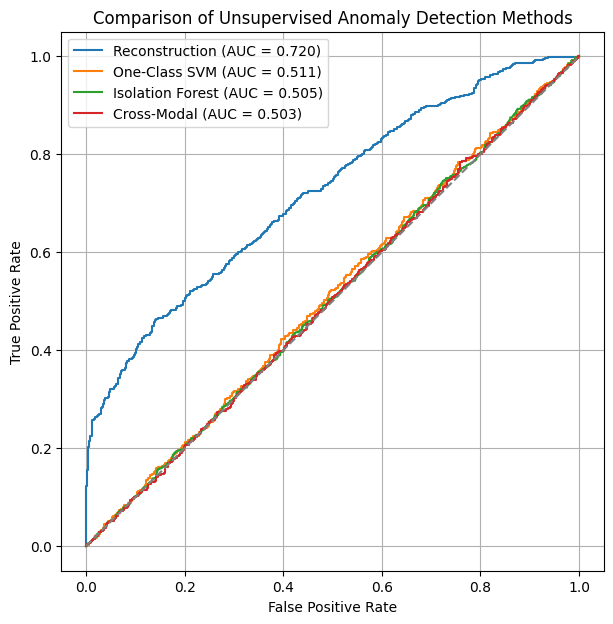

In [26]:
plt.figure(figsize=(7,7))

plt.plot(fpr_rec, tpr_rec, label=f"Reconstruction (AUC = {auc_rec:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"One-Class SVM (AUC = {auc_svm:.3f})")
plt.plot(fpr_iso, tpr_iso, label=f"Isolation Forest (AUC = {auc_iso:.3f})")
plt.plot(fpr_cross, tpr_cross, label=f"Cross-Modal (AUC = {auc_cross:.3f})")

plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparison of Unsupervised Anomaly Detection Methods")
plt.legend()
plt.grid()
plt.show()


## Method Comparison

| Method | AUC |
|--------|------|
| Reconstruction Error | 0.72 |
| One-Class SVM | 0.51 |
| Isolation Forest | 0.50 |
| Cross-Modal Divergence | 0.50 |


Among the evaluated approaches, reconstruction-based detection achieved
the highest AUC of approximately 0.72, while feature-space one-class methods
and cross-modal divergence showed limited separability. This indicates that
pixel-level reconstruction error was the most effective anomaly signal for
structural perturbations in this dataset.



## Inference: Normal vs Anomalous Decision

For inference, anomaly scores are converted into binary decisions using
a threshold derived from normal training data. Samples with reconstruction
error exceeding the threshold are flagged as anomalous.


In [27]:
threshold = np.percentile(normal_rec, 95)
threshold


np.float32(0.00068167556)

The anomaly threshold is computed from the 95th percentile of normal
reconstruction errors. This ensures that only samples with unusually high
error relative to normal training data are flagged as anomalous.


In [28]:
def get_reconstruction_and_error(model, ct_img):
    with torch.no_grad():
        recon, _ = model(ct_img)
        diff = torch.abs(ct_img - recon)
        score = torch.mean(diff**2).item()
    return recon, diff, score


In [29]:
def visualize_inference(model, ct_img, threshold, title_prefix=""):
    model.eval()
    ct_img = ct_img.to(device)

    recon, diff, score = get_reconstruction_and_error(model, ct_img)
    label = "Anomalous" if score > threshold else "Normal"

    ct_np = ct_img[0,0].cpu().numpy()
    recon_np = recon[0,0].cpu().numpy()
    diff_np = diff[0,0].cpu().numpy()

    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(ct_np, cmap="gray")
    plt.title("Original CT")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(recon_np, cmap="gray")
    plt.title("Reconstruction")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(diff_np, cmap="hot")
    plt.title("Error Map")
    plt.axis("off")

    plt.suptitle(
        f"{title_prefix} Prediction: {label} | Score: {score:.5f}",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

    return label, score


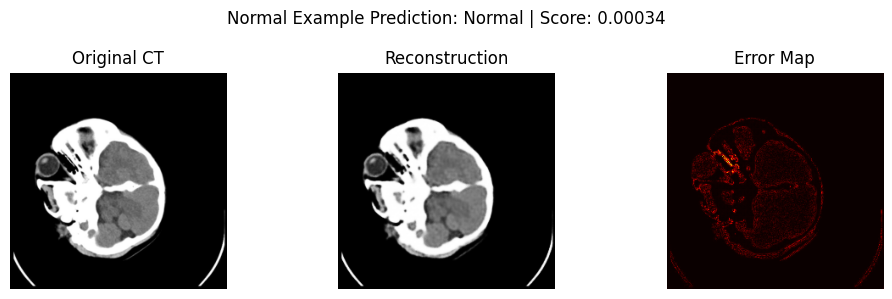

('Normal', 0.0003424715541768819)

In [52]:
ct_batch, _ = next(iter(test_loader))
ct_normal = ct_batch[0:1]

visualize_inference(
    ct_ae,
    ct_normal,
    threshold,
    title_prefix="Normal Example"
)


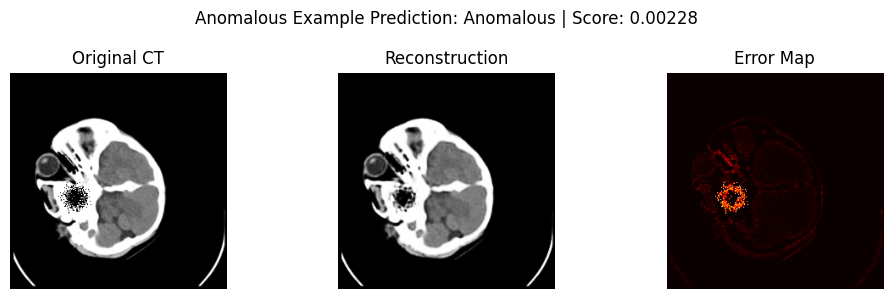

('Anomalous', 0.0022774117533117533)

In [53]:
ct_anom = inject_structural_anomaly_per_image(ct_normal)

visualize_inference(
    ct_ae,
    ct_anom,
    threshold,
    title_prefix="Anomalous Example"
)


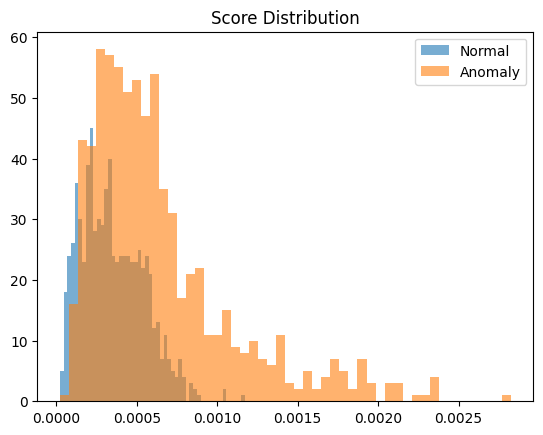

In [54]:
plt.hist(normal_rec, bins=50, alpha=0.6, label="Normal")
plt.hist(anomaly_rec, bins=50, alpha=0.6, label="Anomaly")
plt.legend()
plt.title("Score Distribution")
plt.show()


## Conclusion

This project presents a fully unsupervised cross-modal anomaly detection
framework for paired brain CT–MRI imaging. Separate convolutional
autoencoders were trained exclusively on normal data to learn compact
anatomical representations without relying on labeled abnormal samples.

Three complementary anomaly detection strategies were implemented and
evaluated:
- Reconstruction error in pixel space
- One-class learning in latent feature space (One-Class SVM and Isolation Forest)
- Cross-modal latent representation divergence between CT and MRI

Controlled evaluation using anatomically constrained synthetic structural
anomalies demonstrated meaningful separability between normal and anomalous
samples. The reconstruction-based detector achieved an AUC of approximately
0.72, indicating effective anomaly detection in a fully unsupervised setting.

Feature-space one-class methods and cross-modal divergence showed limited
separability in this setup, suggesting that pixel-level reconstruction error
was the most sensitive signal for detecting structural perturbations in the
current framework.

Overall, the results demonstrate that reconstruction-based modeling provides
a reliable and interpretable mechanism for anomaly detection when labeled
abnormal data is unavailable. This approach is particularly relevant for
clinical screening applications where abnormal cases are rare and annotations
are limited.
